# Signal processing tests

## Setup + helpers

In [228]:
from scipy import fft, stats, signal
import numpy as np
from signal_utils import FTPlotter
import math
import matplotlib.pyplot as plt

ftPlotter = FTPlotter()

In [229]:
def impulse(t: np.ndarray, impulseTime: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    idx = math.floor((impulseTime - t[0]) / dt)
    x[idx] = 1
    return x


def step(t: np.ndarray, stepTime: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    idx = math.floor((stepTime - t[0]) / dt)
    x[idx:] = 1
    return x


def rectPulse(t: np.ndarray, pulseStart: float, pulseEnd: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    startIdx = math.floor((pulseStart - t[0]) / dt)
    endIdx = math.ceil((pulseEnd - t[0]) / dt)
    x[startIdx:endIdx] = 1
    length = endIdx - startIdx
    return x, length


t = np.linspace(0, 16, 32)
rectPulse(t, 2, 3)


def sinc(t: np.ndarray, centerTime: float, width: float = 1.0):
    return np.sinc((t - centerTime) / width)

## Common DFT pairs

Use helpers to easily create signals and visualize common DFT pairs. 

Notes:
* fft/fftfreq also returns negative frequencies. This is technically redundant since the DFT is periodic i.e. the magnitudes are symmetric with respect to the vertical axis and the phases with respect to the origin at multiples of the nyquist frequency. 

* "Weird" graphs (e.g. DFT{impulse[t]}) on rectagular coordinates are due to the samples falling at different "moments" of the waveform (not perfectly aligned with peaks or troughs); thus when they are connected with lines they look different to the ideal, continuous, fourier transform. There's also the possibility of aliasing, which distorts things further. 

* Phases near t=0 may be a little bit unpredictable sometimes. Ideally, it should be a horizontal line with left-right symmetrical time domain signals. 

In [230]:
N = 256
startTime = -25
endTime = 25
t = np.linspace(startTime, endTime, N)
dt = t[1] - t[0]
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfftfreq.html
# f = fft.rfftfreq(N, d=dt)  # 0 <= f < Nyquist f
f = fft.rfftfreq(N, d=dt) * dt  # 0 <= f < 1/2

print(f"Sampling T = {dt:.2f}, Sampling f = {1/dt:.2f}, Nyquist f = {1/(2*dt):.2f}")

Sampling T = 0.20, Sampling f = 5.10, Nyquist f = 2.55


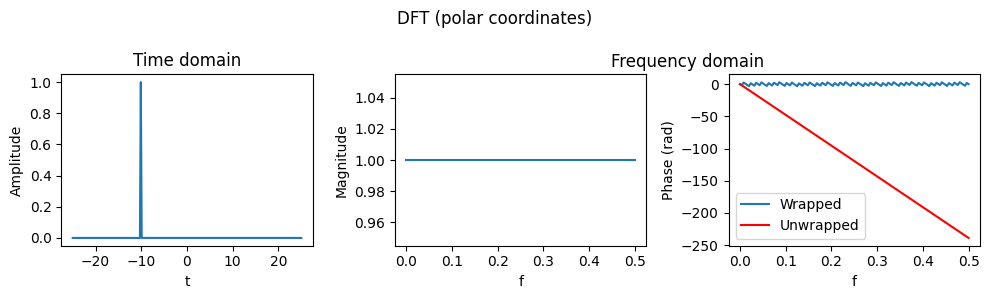

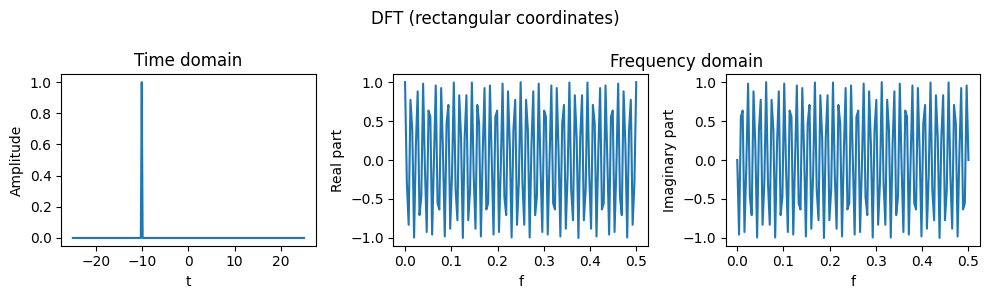

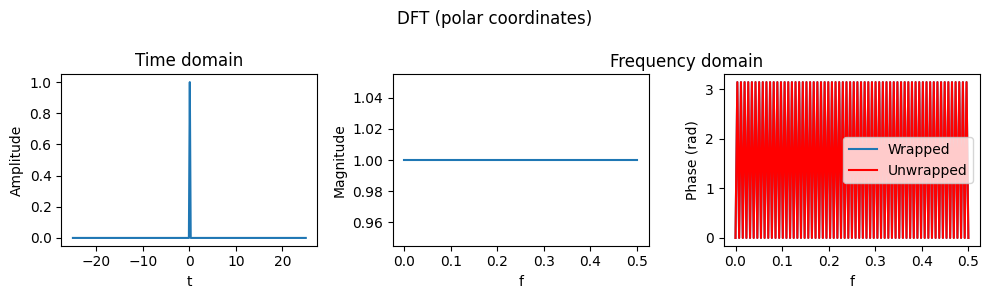

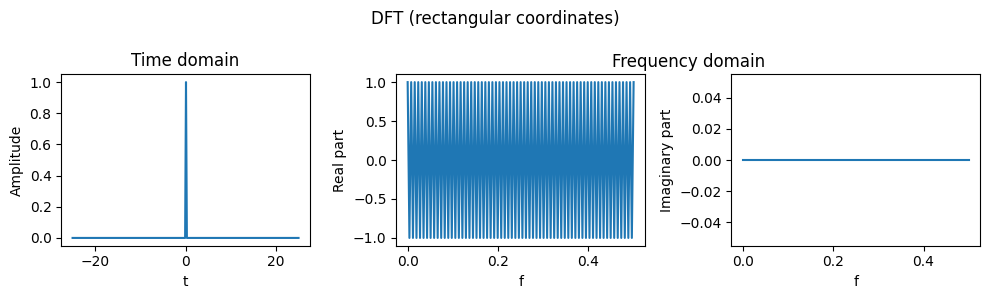

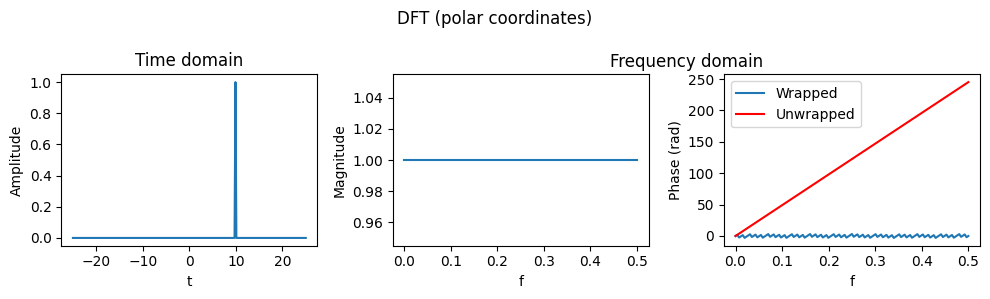

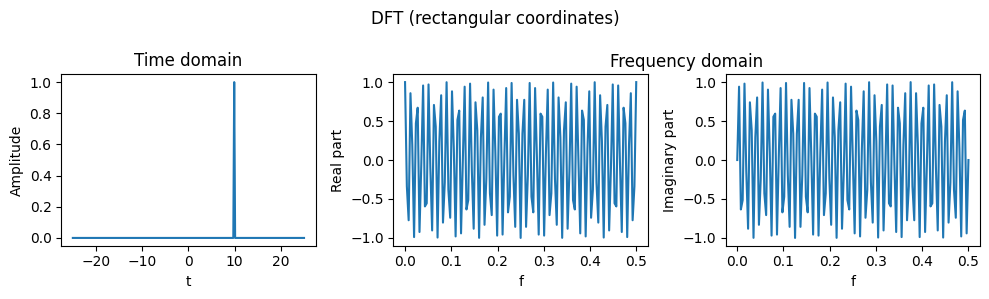

In [231]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html#scipy.fft.rfft

x = impulse(t, -10)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)

x = impulse(t, 0.25)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)

x = impulse(t, 10)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)

## Convolution

### Signal + different types of noise

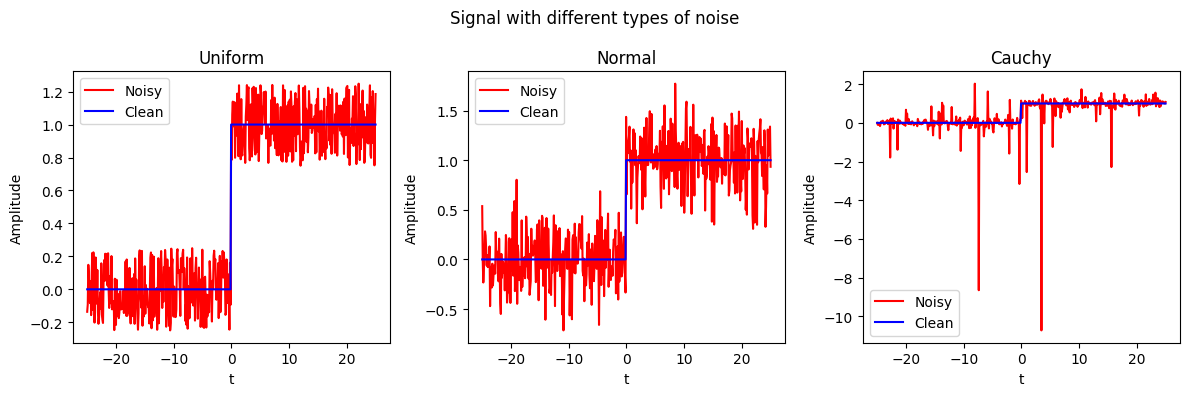

In [232]:
N = 512
startTime = -25
endTime = 25
t, dt = np.linspace(startTime, endTime, num=N, retstep=True)
# x = np.sin(t)
x = step(t, 0)
seed = 12345  # Use always the same seed for reproducibility
rng = np.random.default_rng(seed)

# Noise
# Simple
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html#scipy.stats.uniform
uniformNoise = stats.uniform.rvs(loc=-0.25, scale=0.5, size=N, random_state=rng)

# Common in nature
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm
normalNoise = stats.norm.rvs(loc=0, scale=0.25, size=N, random_state=rng)

# Heavier tails, more likely to produce outliers, almost pathological (undefined mean and variance)
# Keep scale low, otherwise the outliers are too strong
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html#scipy.stats.cauchy
# https://en.wikipedia.org/wiki/Cauchy_distribution
cauchyNoise = stats.cauchy.rvs(loc=0, scale=0.25 / 4, size=N, random_state=rng)

# Common graph
noiseTypes = ["Uniform", "Normal", "Cauchy"]
noisySignals = [x + uniformNoise, x + normalNoise, x + cauchyNoise]
fig, axes = plt.subplots(1, len(noiseTypes), figsize=(12, 4))
fig.suptitle("Signal with different types of noise")
for i, (noise, noisyx) in enumerate(zip(noiseTypes, noisySignals)):
    axes[i].plot(t, noisyx, color="red", label="Noisy")
    axes[i].plot(t, x, color="blue", label="Clean")
    axes[i].legend()
    axes[i].set_title(noise)
    axes[i].set_xlabel("t")
    axes[i].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### Boxcar filter (rectangular pulse) 

Observations: longer kernels smooth the signal more, but at the cost of amplitude attenuation and waveform distortion (specially with stronger/impulsive noise). A short-ish kernel seems to be a good compromise (8-16 samples, at least in this case). A triangual or or gaussian kernel would probably accentuate these effects even more.

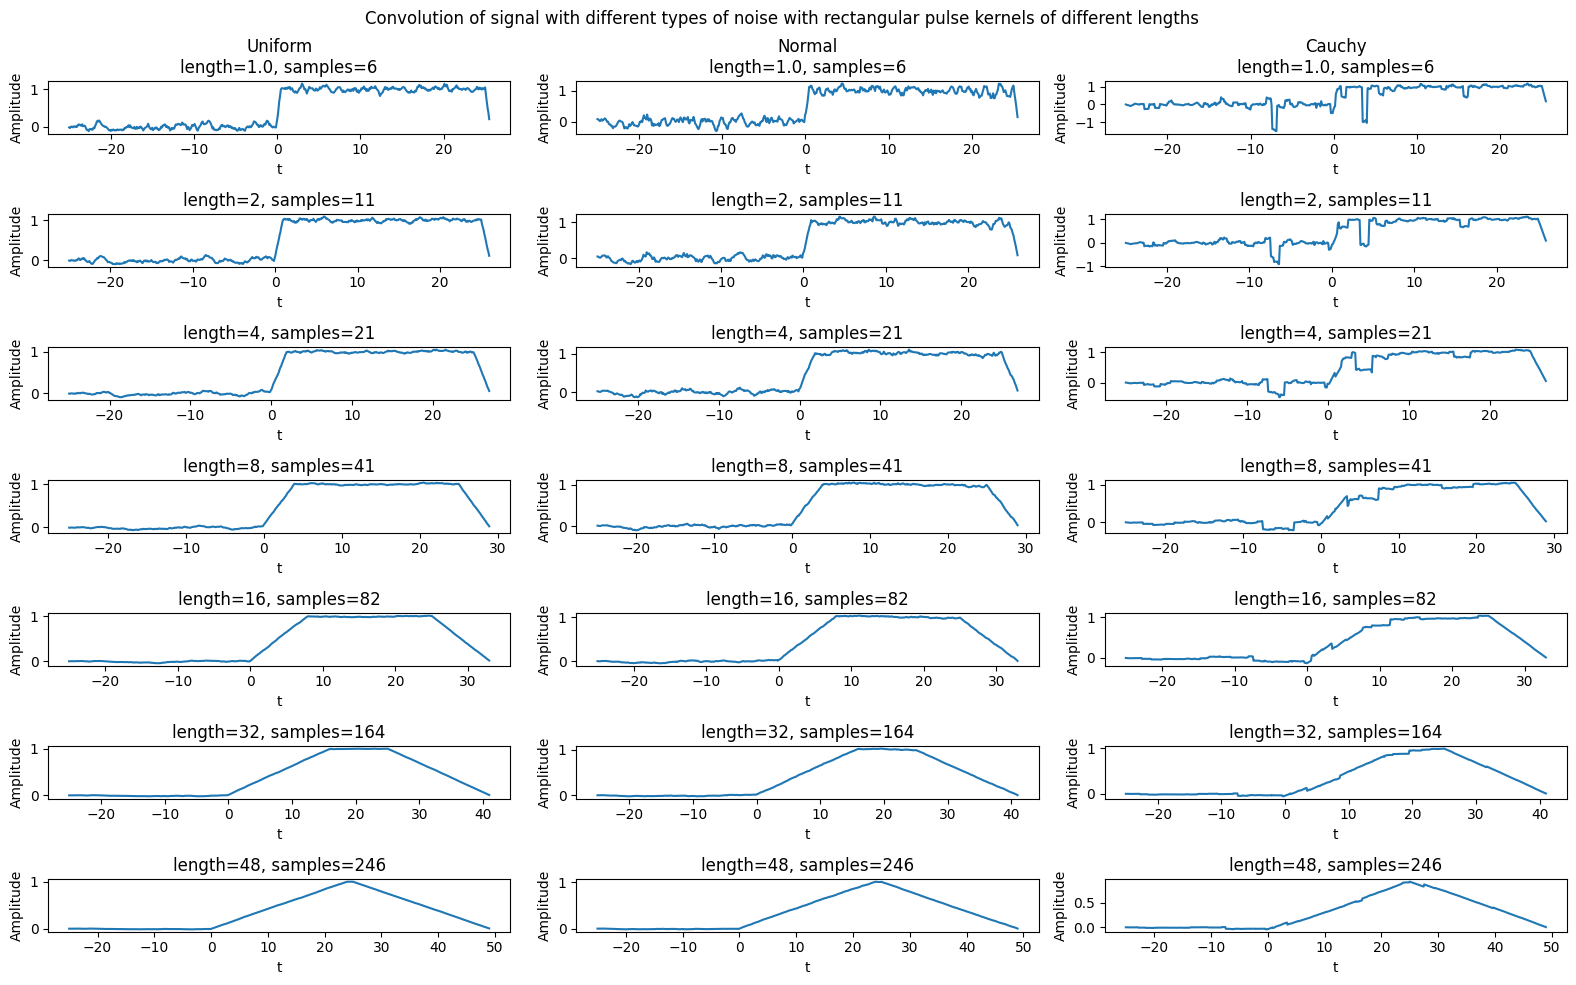

In [233]:
kernelWidth = [0.5, 1, 2, 4, 8, 16, 24]  # Rect pulse kernel time length

fig, axes = plt.subplots(len(kernelWidth), len(noisySignals), figsize=(16, 10))
fig.suptitle(
    "Convolution of signal with different types of noise with rectangular pulse kernels of different lengths"
)
for i, kernelWidth in enumerate(kernelWidth):
    for j, noisyx in enumerate(noisySignals):
        kernelStart = -kernelWidth / 2
        kernelEnd = kernelWidth / 2
        tKernel = np.arange(
            kernelStart, kernelEnd, step=dt
        )  # Use the same sampling period as the signal
        kernel, kernelSampleLength = rectPulse(tKernel, kernelStart, kernelEnd)
        kernel = 1 / kernelSampleLength * kernel  # Normalize to preserve amplitude
        convolved = signal.convolve(noisyx, kernel)
        tTotal = np.arange(startTime, endTime + kernelSampleLength * dt, dt)

        axes[i, j].plot(tTotal, convolved)
        axes[i, j].set_title(
            f"{noiseTypes[j]}\nlength={kernelWidth * 2}, samples={kernelSampleLength}"
            if i == 0
            else f"length={kernelWidth * 2}, samples={kernelSampleLength}"
        )
        axes[i, j].set_xlabel("t")
        axes[i, j].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### Sinc kernel

Observations: better noise reduction than the boxcar filter and amplitude preservation, at the cost of some ringing artifacts (Gibbs-like effect, messier with strong/impulsive noise). Shifts in time with greater kernel widths. 

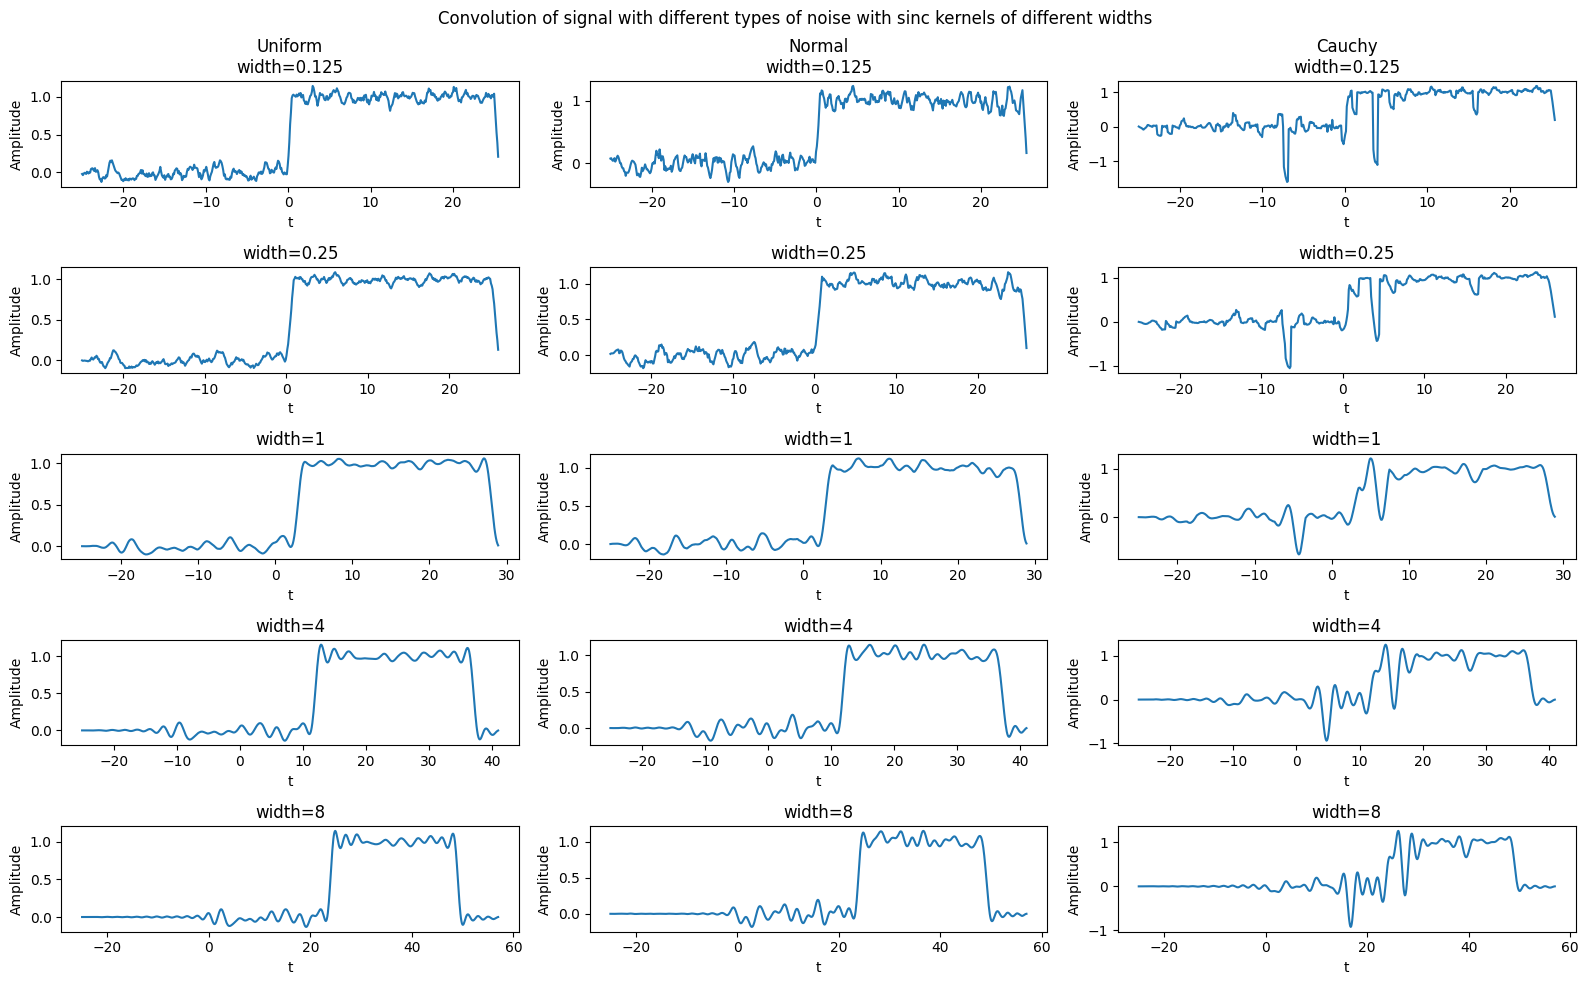

In [235]:
kernelWidth = [1 / 8, 1 / 4, 1, 4, 8]

fig, axes = plt.subplots(len(kernelWidth), len(noisySignals), figsize=(16, 10))
fig.suptitle(
    "Convolution of signal with different types of noise with sinc kernels of different widths"
)
for i, kernelWidth in enumerate(kernelWidth):
    for j, noisyx in enumerate(noisySignals):
        kernelStart = -kernelWidth * 2
        kernelEnd = kernelWidth * 2
        tKernel = np.arange(
            kernelStart, kernelEnd, step=dt
        )  # Use the same sampling period as the signal
        kernel = sinc(tKernel, kernelWidth)
        kernel = 1 / np.sum(kernel) * kernel  # Normalize to preserve amplitude
        convolved = signal.convolve(noisyx, kernel)
        tTotal = np.arange(startTime, startTime + len(convolved) * dt, dt)

        axes[i, j].plot(tTotal, convolved)
        axes[i, j].set_title(
            f"{noiseTypes[j]}\nwidth={kernelWidth}"
            if i == 0
            else f"width={kernelWidth}"
        )
        axes[i, j].set_xlabel("t")
        axes[i, j].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()